# Slither vs Haiku — Analysis

Reads `data/stage3_scored/scores.json` from `02_comparison.ipynb`.

667 files scored: 182 vulnerable, 485 clean. 11 `bad_randomness` files and 45 Slither failures
excluded from both tools.

## Setup

In [1]:
import json, os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

os.chdir("/Users/mk/Desktop/mk/AuditMind")
S = json.load(open("data/stage3_scored/scores.json"))

CATS = ["reentrancy", "access_control", "unchecked_low_level_calls",
        "denial_of_service", "time_manipulation"]
SHORT = {"reentrancy":"reentrancy", "access_control":"access ctrl",
         "unchecked_low_level_calls":"unchecked calls",
         "denial_of_service":"DoS", "time_manipulation":"time manip"}
F = json.load(open("data/stage3_scored/forced_scores.json"))
# fold the forced-choice arm in alongside the other three
S["pooled"]["haiku_forced"]   = F["pooled_typeaware"]
S["by_source"]["smartbugs"]["haiku_forced"] = F["by_source"]["smartbugs"]
S["by_source"]["swc"]["haiku_forced"]       = F["by_source"]["swc"]
S["by_source"]["dappscan"]["haiku_forced"]  = F["by_source"]["dappscan"]
S["clean_fp"]["haiku_forced"] = F["clean_fp"]
for t, v in F["localization"]["sweep"].items():
    S["localization"]["sweep"][t]["haiku_forced"] = v

R = json.load(open("data/stage3_scored/routed_scores.json"))
S["pooled"]["routed"]   = R["pooled_typeaware"]
for _s in ("smartbugs", "swc", "dappscan"):
    S["by_source"][_s]["routed"] = R["by_source"][_s]
S["clean_fp"]["routed"] = R["clean_fp"]
for t, v in R["localization"]["sweep"].items():
    S["localization"]["sweep"][t]["routed"] = v

ARMS = ["slither_hm", "slither_all", "haiku", "haiku_forced", "routed"]
LABEL = {"slither_hm":"Slither H/M", "slither_all":"Slither all", "haiku":"Haiku multi-label", "haiku_forced":"Haiku forced", "routed":"Routed"}
TICK = {"slither_hm":"Slither\nH/M", "slither_all":"Slither\nall",
        "haiku":"Haiku\nmulti-label", "haiku_forced":"Haiku\nforced",
        "routed":"Routed"}

print(S["n_scored"], "files scored")
pd.DataFrame({LABEL[a]: S["pooled"][a]["macro"] for a in ARMS}).T.round(3)

667 files scored


,precision,recall,f1,specificity
Slither H/M,0.310,0.404,0.350,0.973
Slither all,0.285,0.678,0.386,0.909
Haiku multi-label,0.312,0.832,0.430,0.882
Haiku forced,0.495,0.568,0.485,0.960
Routed,0.532,0.685,0.558,0.960


## Theme

In [2]:
THEMES = {
    "slate": dict(bg="#F5F5F5", ink="#303841", muted="#76ABAE", hot="#FF5722"),
    "navy":  dict(bg="#EAECF0", ink="#000000", muted="#233D4D", hot="#FE7F2D"),
}
T = THEMES["navy"]

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "figure.facecolor": T["bg"], "axes.facecolor": T["bg"],
    "savefig.facecolor": T["bg"],
    "text.color": T["ink"], "axes.labelcolor": T["ink"],
    "xtick.color": T["ink"], "ytick.color": T["ink"], "axes.edgecolor": T["ink"],
    "axes.grid": True, "grid.color": "#CCCCCC", "grid.linewidth": .5,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120,
})

COLOR = {"slither_hm": T["muted"], "slither_all": "#8FA6B2",
         "haiku": T["hot"], "haiku_forced": "#C2410C",   # orange / dark orange
         "routed": "#76ABAE"}                            # teal - the combination

def bare(ax):
    ax.grid(axis="x", visible=False)
    return ax
print(T)

{'bg': '#EAECF0', 'ink': '#000000', 'muted': '#233D4D', 'hot': '#FE7F2D'}


---
## 1 - Macro averages

Mean across the five categories. Every metric weighted equally regardless of category size.

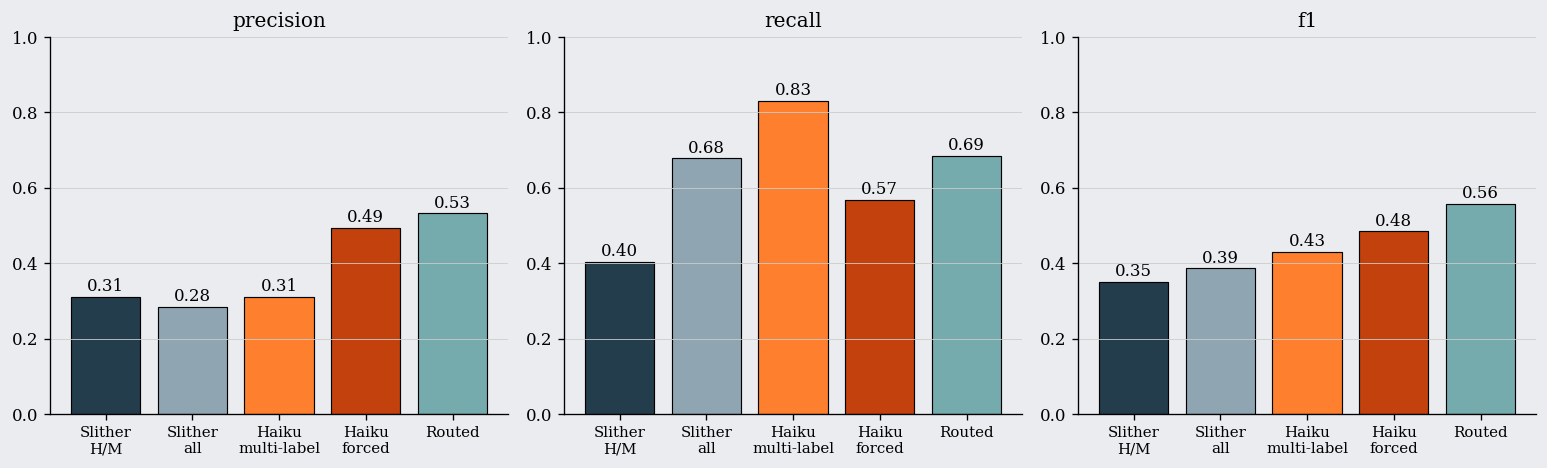

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, m in zip(axes, ["precision", "recall", "f1"]):
    vals = [S["pooled"][a]["macro"][m] for a in ARMS]
    ax.bar([TICK[a] for a in ARMS], vals,
           color=[COLOR[a] for a in ARMS], edgecolor=T["ink"], linewidth=.7)
    for i, v in enumerate(vals):
        ax.text(i, v + .015, f"{v:.2f}", ha="center", fontsize=10, color=T["ink"])
    ax.set_title(m, fontsize=12); ax.set_ylim(0, 1)
    ax.tick_params(axis="x", labelsize=9)
    bare(ax)
plt.tight_layout(); plt.show()

→ Precision splits the arms in two. Slither and Haiku multi-label sit at 0.31; forcing Haiku to one answer lifts it to 0.49, and routing the two tools by category reaches 0.53.

→ Recall runs the other way. Haiku multi-label 0.83, routed 0.69, forced 0.57, Slither H/M 0.40.

→ At 0.31 precision roughly two flags in three are wrong. Multi-label Haiku is not more accurate when it fires; it fires far more often and so catches more of what is really there. Routing is the only arm that raises precision without giving up most of that recall.

---
## 2 - Per category F1

Ground-truth positives: reentrancy 47, access control 45, unchecked calls 56, DoS 22, time 16.

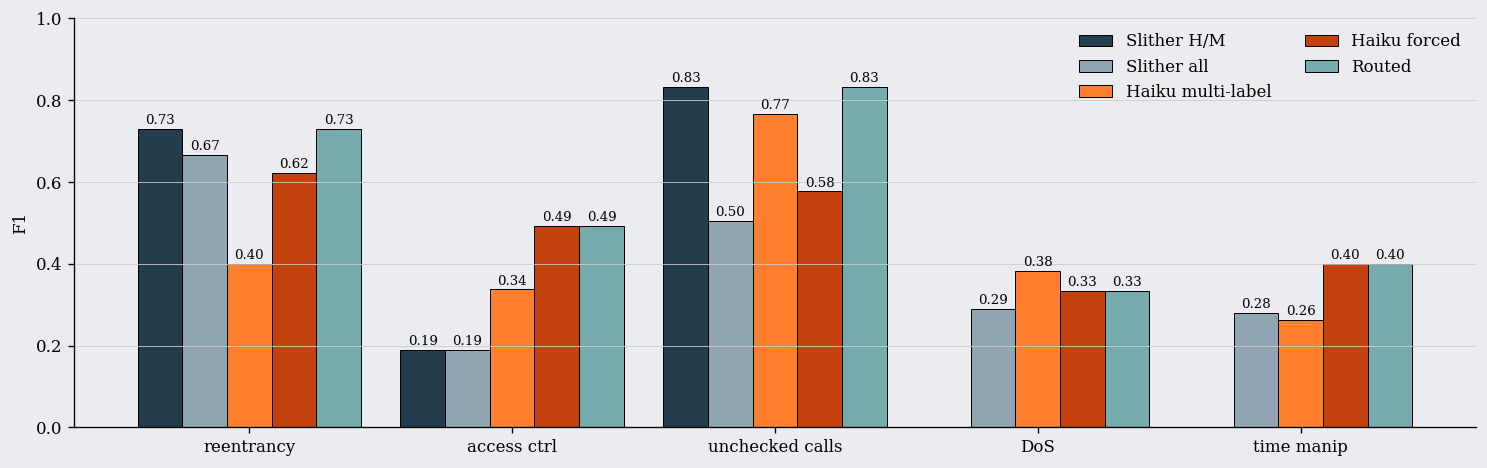

In [4]:
fig, ax = plt.subplots(figsize=(12.5, 4))
x = np.arange(len(CATS)); w = .17
for k, a in enumerate(ARMS):
    v = [S["pooled"][a]["per_category"][c]["f1"] for c in CATS]
    ax.bar(x + (k-2)*w, v, w, label=LABEL[a],
           color=COLOR[a], edgecolor=T["ink"], linewidth=.6)
    for i, val in enumerate(v):
        if val > 0:
            ax.text(x[i]+(k-2)*w, val+.012, f"{val:.2f}",
                    ha="center", fontsize=8, color=T["ink"])
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS])
ax.set_ylabel("F1"); ax.set_ylim(0, 1); ax.legend(frameon=False, ncol=2)
bare(ax); plt.tight_layout(); plt.show()

→ Slither H/M has no bar at all for DoS and time manipulation. Not a low score — no qualifying detector exists, so it cannot score.

→ The two tools own opposite halves. Slither takes reentrancy 0.73 and unchecked calls 0.83; Haiku takes access control 0.49, DoS 0.38 and time manipulation 0.40. Neither is close on the other's categories.

→ Reentrancy is Haiku's weak spot, 0.40 multi-label against Slither's 0.73. Routed matches the better tool in every column, which is what section 12 is about.

---
## 3 - Precision vs recall

Up and right is better. Marker size scales with ground-truth positives.

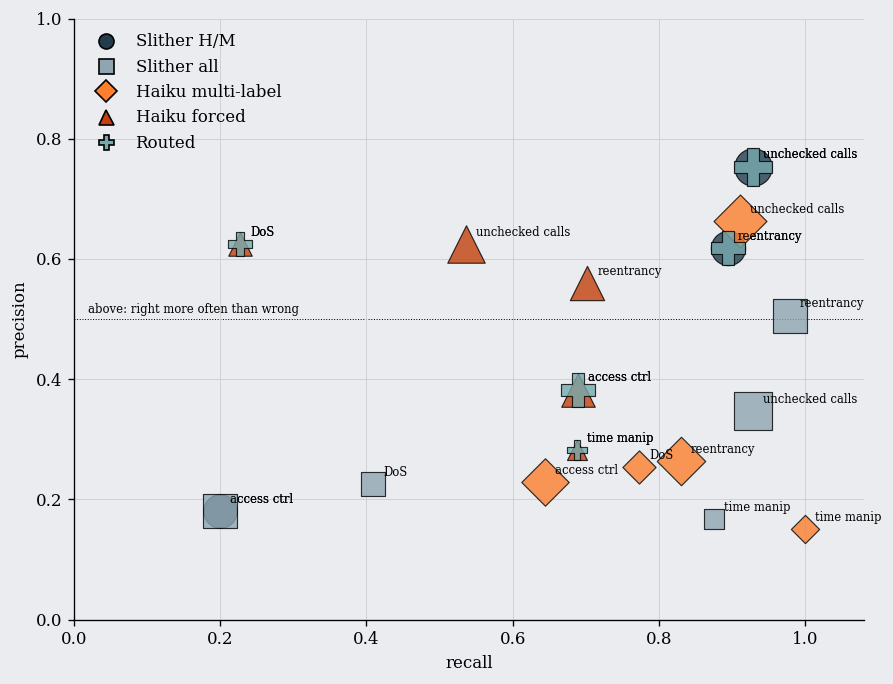

,Slither H/M,Slither all,Haiku multi-label,Haiku forced,Routed
reentrancy,"(42, 26)","(46, 45)","(39, 109)","(33, 26)","(42, 26)"
access_control,"(9, 41)","(9, 41)","(29, 98)","(31, 50)","(31, 50)"
unchecked_low_level_calls,"(52, 17)","(52, 98)","(51, 26)","(30, 18)","(52, 17)"
denial_of_service,"(0, 0)","(9, 31)","(17, 50)","(5, 3)","(5, 3)"
time_manipulation,"(0, 0)","(14, 70)","(16, 90)","(11, 28)","(11, 28)"


In [5]:
MARK = {"slither_hm": "o", "slither_all": "s", "haiku": "D", "haiku_forced": "^", "routed": "P"}

fig, ax = plt.subplots(figsize=(7.6, 5.8))
for a in ARMS:
    for c in CATS:
        s = S["pooled"][a]["per_category"][c]
        if s["tp"] + s["fp"] == 0: continue
        ax.scatter(s["recall"], s["precision"], s=s["n_pos"]*9, marker=MARK[a],
                   color=COLOR[a], edgecolor=T["ink"], linewidth=.7, alpha=.8, zorder=3)
        ax.annotate(SHORT[c], (s["recall"], s["precision"]), fontsize=7,
                    xytext=(6, 5), textcoords="offset points", color=T["ink"])
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_xlim(0, 1.08); ax.set_ylim(0, 1)
ax.axhline(.5, color=T["ink"], lw=.6, ls=":", zorder=1)
ax.text(.02, .51, "above: right more often than wrong", fontsize=7, color=T["ink"])
ax.legend(handles=[plt.Line2D([], [], marker=MARK[a], color="none",
                              markerfacecolor=COLOR[a], markeredgecolor=T["ink"],
                              markersize=9, label=LABEL[a]) for a in ARMS],
          frameon=False, loc="upper left")
plt.tight_layout(); plt.show()

# access control is identical for both Slither mappings - markers would otherwise overlap exactly
pd.DataFrame({LABEL[a]: {c: (S["pooled"][a]["per_category"][c]["tp"],
                             S["pooled"][a]["per_category"][c]["fp"])
                         for c in CATS} for a in ARMS})

→ Only five of the twenty-five points clear the 0.5 precision line: Slither's reentrancy (0.62) and unchecked calls (0.75), and forced-choice Haiku's reentrancy, unchecked calls and DoS. Everything else is wrong more often than right when it fires.

→ Haiku multi-label sits far right and low — recall 0.64 to 1.00, precision 0.15 to 0.66. Forced choice pulls the same model left and up, trading recall for precision.

→ Access control is identical for both Slither mappings (9 TP, 41 FP), so those two markers land on the same point. The table below gives TP/FP directly.

---
## 4 - False positives on clean code

485 clean files. A flag here is always wrong.

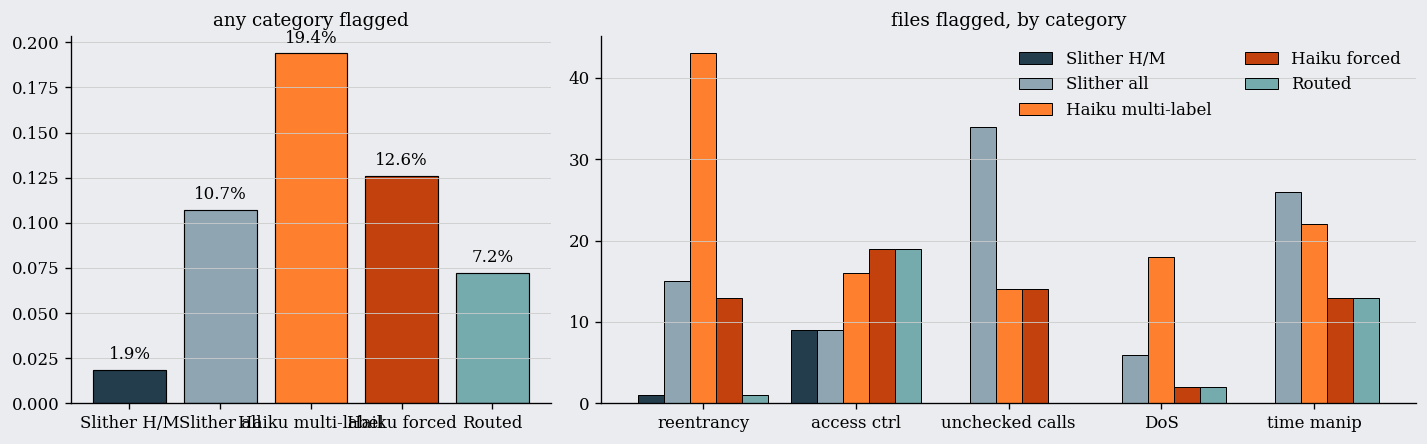

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8),
                         gridspec_kw={"width_ratios": [1, 1.7]})

n_clean = S["clean_fp"]["haiku"]["n_clean"]
rates = [S["clean_fp"][a]["any"] / n_clean for a in ARMS]
axes[0].bar([LABEL[a] for a in ARMS], rates,
            color=[COLOR[a] for a in ARMS], edgecolor=T["ink"], linewidth=.7)
for i, v in enumerate(rates):
    axes[0].text(i, v + .006, f"{v:.1%}", ha="center", fontsize=10, color=T["ink"])
axes[0].set_title("any category flagged", fontsize=11); bare(axes[0])

x = np.arange(len(CATS)); w = .17
for k, a in enumerate(ARMS):
    v = [S["clean_fp"][a]["per_category"][c] for c in CATS]
    axes[1].bar(x + (k-2)*w, v, w, label=LABEL[a],
                color=COLOR[a], edgecolor=T["ink"], linewidth=.6)
axes[1].set_xticks(x); axes[1].set_xticklabels([SHORT[c] for c in CATS])
axes[1].set_title("files flagged, by category", fontsize=11)
axes[1].legend(frameon=False, ncol=2); bare(axes[1])
plt.tight_layout(); plt.show()

→ The number that decides production use. Slither H/M fires on 1.9% of clean files, Haiku multi-label on 19.4% — ten times noisier. Forced choice cuts that to 12.6% and routing to 7.2%.

→ Haiku's clean-file noise is concentrated in reentrancy, 43 of 485 files, the same category where its F1 is weakest. Its reentrancy problem is over-flagging, not blindness.

→ Routing inverts that profile: reentrancy drops to 1 clean file because Slither answers it there, and what remains is access control (19) and time manipulation (13), the categories Haiku still owns.

---
## 5 - Severity threshold

Same scan, same stored output. Only the cutoff on what counts as a detection changes.

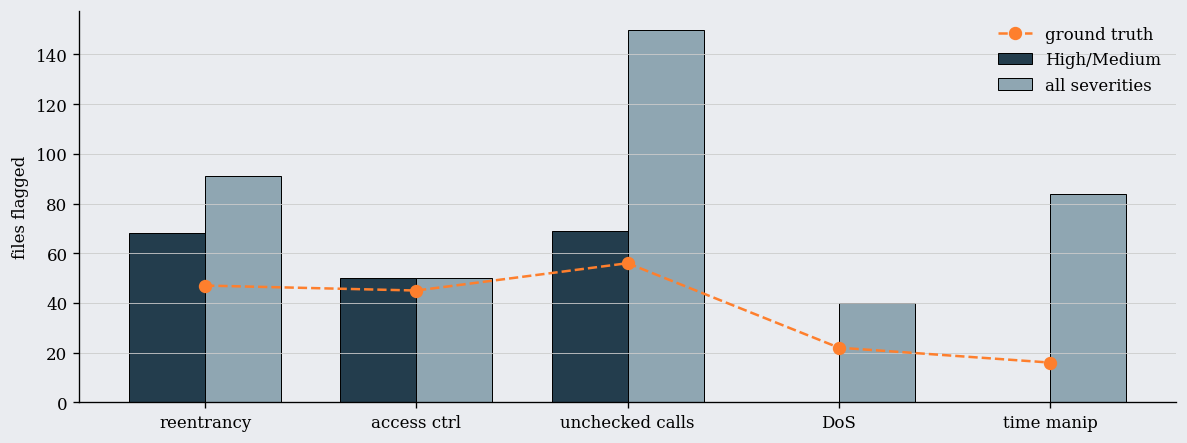

,category,n_pos,flags H/M,flags all,F1 H/M,F1 all
0,reentrancy,47,68,91,0.73,0.67
1,access ctrl,45,50,50,0.19,0.19
2,unchecked calls,56,69,150,0.83,0.50
3,DoS,22,0,40,0.00,0.29
4,time manip,16,0,84,0.00,0.28


In [7]:
rows = []
for c in CATS:
    hm, al = (S["pooled"]["slither_hm"]["per_category"][c],
              S["pooled"]["slither_all"]["per_category"][c])
    rows.append({"category": SHORT[c], "n_pos": hm["n_pos"],
                 "flags H/M": hm["tp"]+hm["fp"], "flags all": al["tp"]+al["fp"],
                 "F1 H/M": round(hm["f1"], 2), "F1 all": round(al["f1"], 2)})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 3.8))
x = np.arange(len(CATS)); w = .36
ax.bar(x - w/2, df["flags H/M"], w, label="High/Medium",
       color=T["muted"], edgecolor=T["ink"], linewidth=.6)
ax.bar(x + w/2, df["flags all"], w, label="all severities",
       color="#8FA6B2", edgecolor=T["ink"], linewidth=.6)
ax.plot(x, df["n_pos"], "o--", color=T["hot"], label="ground truth", zorder=4, ms=7)
ax.set_xticks(x); ax.set_xticklabels(df["category"])
ax.set_ylabel("files flagged"); ax.legend(frameon=False)
bare(ax); plt.tight_layout(); plt.show()
df

→ All severities is not a free recall win. Time manipulation goes 0 to 84 flags for 16 real cases; unchecked calls 69 to 150 for 56.

→ Reentrancy F1 falls 0.73 to 0.67 even as recall rises — the added flags are mostly wrong.

→ Access control is identical in both columns, the one category where the severity threshold changes nothing.

---
## 6 - By source

Each source scored against the shared clean pool. SWC is n=10 and directional only.

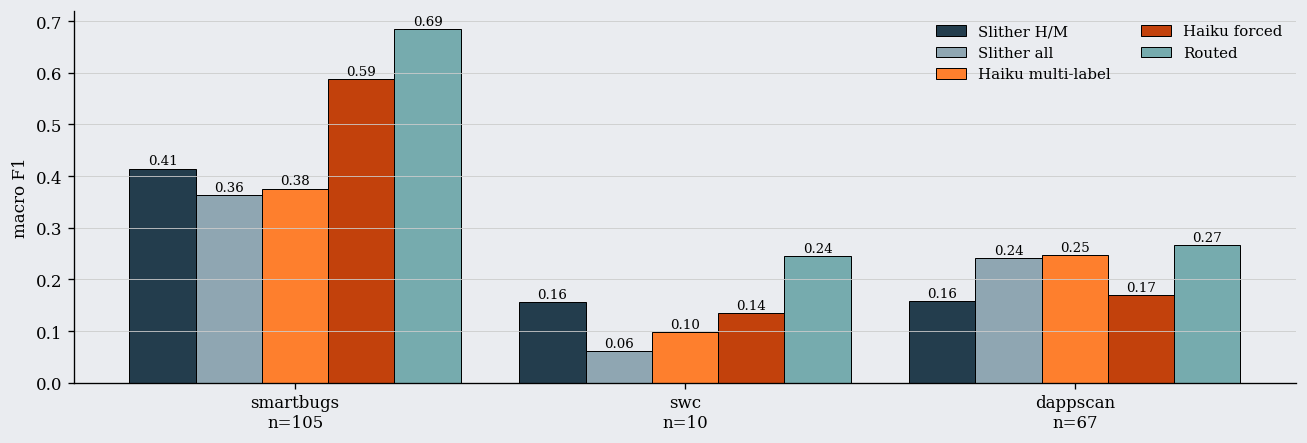

In [8]:
bs = S["by_source"]
srcs = ["smartbugs", "swc", "dappscan"]
fig, ax = plt.subplots(figsize=(11, 3.8))
x = np.arange(len(srcs)); w = .17
for k, a in enumerate(ARMS):
    v = [bs[s][a]["f1"] for s in srcs]
    ax.bar(x + (k-2)*w, v, w, label=LABEL[a],
           color=COLOR[a], edgecolor=T["ink"], linewidth=.6)
    for i, val in enumerate(v):
        ax.text(x[i]+(k-2)*w, val+.008, f"{val:.2f}", ha="center", fontsize=8, color=T["ink"])
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\nn={bs[s]['n_vuln']}" for s in srcs])
ax.set_ylabel("macro F1"); ax.legend(frameon=False, ncol=2, fontsize=9)
bare(ax); plt.tight_layout(); plt.show()

→ Slither is strongest on SmartBugs (0.41), the academic single-file corpus its detectors were tuned against, and drops to 0.16 on DAppSCAN.

→ Forced choice is far better on SmartBugs (0.59) — those files are single-bug by construction, so one answer is the right shape. On DAppSCAN it falls to 0.17 while multi-label leads at 0.25: real audited contracts carry several issues at once, and discarding everything after the first costs more than the precision it buys.

→ Routing wins both (0.69 and 0.27), but the gap between sources is the story. Every arm loses more than half its F1 moving from academic examples to real audited code. SWC is n=10 and directional only.

---
## 7 - Localization

SmartBugs only, 106 file-category pairs — the only source with per-line ground truth.
Haiku's line numbers are mapped back from the stripped file to the original before comparing.

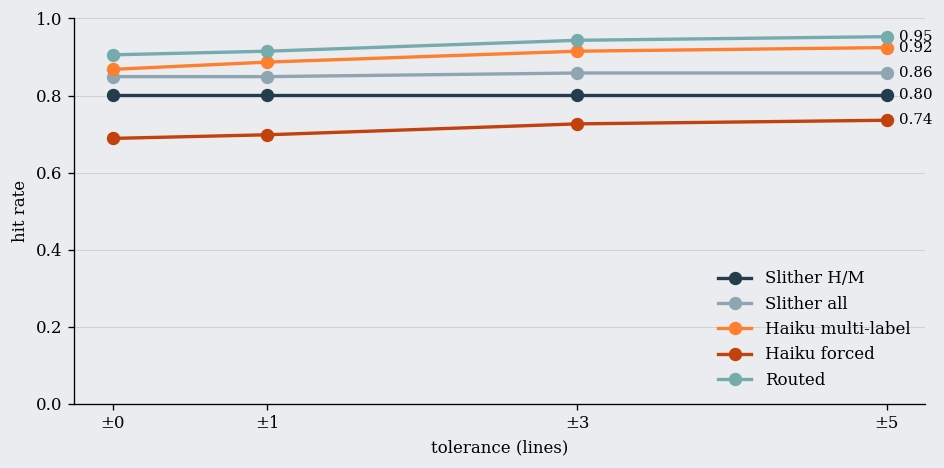

In [9]:
sw = S["localization"]["sweep"]
tols = sorted(int(t) for t in sw)
fig, ax = plt.subplots(figsize=(8, 4))
for a in ARMS:
    y = [sw[str(t)][a] if str(t) in sw else sw[t][a] for t in tols]
    ax.plot(tols, y, "o-", color=COLOR[a], label=LABEL[a], ms=7, lw=2)
    ax.text(tols[-1]+.08, y[-1], f"{y[-1]:.2f}", fontsize=9, color=T["ink"], va="center")
ax.set_xlabel("tolerance (lines)"); ax.set_ylabel("hit rate")
ax.set_xticks(tols); ax.set_xticklabels([f"±{t}" for t in tols])
ax.set_ylim(0, 1); ax.legend(frameon=False, loc="lower right")
bare(ax); plt.tight_layout(); plt.show()

→ Routing localizes best, 0.91 exact, ahead of Haiku multi-label at 0.87 and Slither at 0.80 — it takes Slither's line numbers on the categories Slither answers.

→ Forced choice is the worst at 0.69. Constrained to one answer it often picks the right category but points at a different line than the dataset records.

→ The curves are nearly flat, so a miss is a miss by more than five lines rather than an off-by-one. Widening the tolerance buys almost nothing for any arm.

---
## 8 - Cost

Slither is wall-clock on an M-series Mac. Haiku is tokens at Batch API rates.

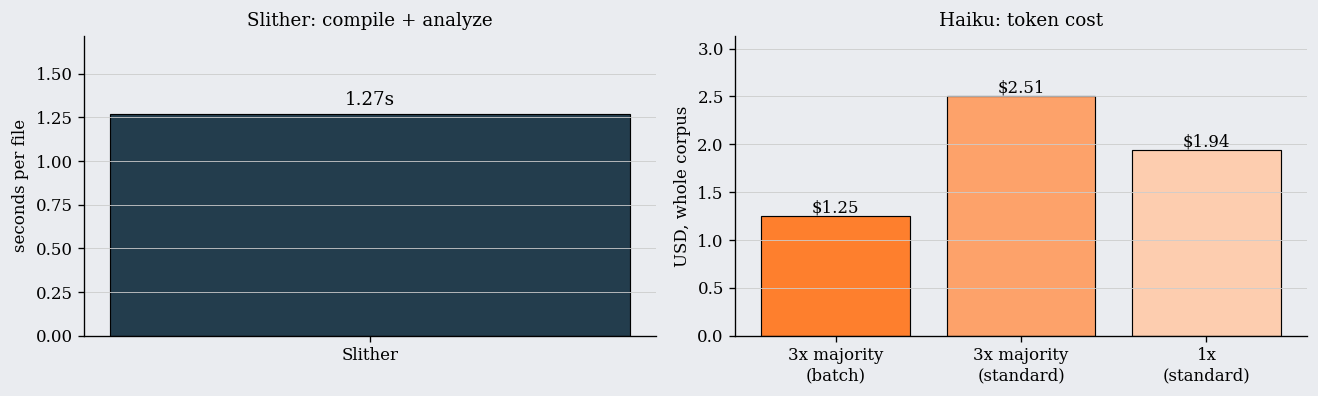

Slither 899s total over 723 files
Haiku 2,012,398 in / 98,666 out, 876 calls


In [10]:
c = S["cost"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

sl_s = c["slither"]["mean_s"]
axes[0].bar(["Slither"], [sl_s], width=.45,
            color=T["muted"], edgecolor=T["ink"], linewidth=.7)
axes[0].text(0, sl_s + .05, f"{sl_s:.2f}s", ha="center", fontsize=11, color=T["ink"])
axes[0].set_ylabel("seconds per file")
axes[0].set_title("Slither: compile + analyze", fontsize=11)
axes[0].set_ylim(0, sl_s * 1.35); bare(axes[0])

lbl = ["3x majority\n(batch)", "3x majority\n(standard)", "1x\n(standard)"]
val = [c["haiku"]["usd_batch"], c["haiku"]["usd_standard"], c["haiku"]["usd_standard_1x"]]
axes[1].bar(lbl, val, color=[T["hot"], "#FDA26A", "#FDCDAF"],
            edgecolor=T["ink"], linewidth=.7)
for i, v in enumerate(val):
    axes[1].text(i, v + .04, f"${v:.2f}", ha="center", fontsize=10, color=T["ink"])
axes[1].set_ylabel("USD, whole corpus")
axes[1].set_title("Haiku: token cost", fontsize=11)
axes[1].set_ylim(0, max(val) * 1.25); bare(axes[1])
plt.tight_layout(); plt.show()

print(f"Slither {c['slither']['total_s']:.0f}s total over {c['slither']['n']} files")
print(f"Haiku {c['haiku']['input_tokens']:,} in / {c['haiku']['output_tokens']:,} out, "
      f"{c['haiku']['n_calls']} calls")

→ Slither is 1.2s per file and free. Haiku is $1.25 for the whole corpus at batch rates.

→ Neither is a real constraint at this scale, so cost does not decide the lane.

---
## 9 - Stability

3 calls at temperature 0 on a stratified 100-file sample, 1 call elsewhere.

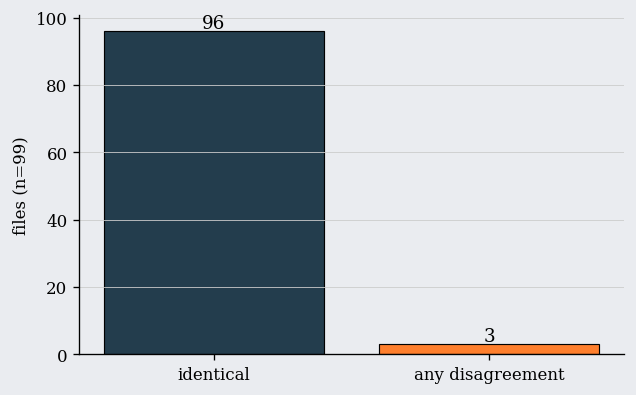

mean disagreement rate 0.0061


In [11]:
hk = json.load(open("data/stage2_results/haiku_results.json"))
d = [r["disagreement_rate"] for r in hk if r["disagreement_rate"] is not None]
unstable = sum(1 for x in d if x > 0)

fig, ax = plt.subplots(figsize=(5.4, 3.4))
ax.bar(["identical", "any disagreement"], [len(d)-unstable, unstable],
       color=[T["muted"], T["hot"]], edgecolor=T["ink"], linewidth=.7)
for i, v in enumerate([len(d)-unstable, unstable]):
    ax.text(i, v+1, str(v), ha="center", fontsize=11, color=T["ink"])
ax.set_ylabel(f"files (n={len(d)})"); bare(ax)
plt.tight_layout(); plt.show()
print(f"mean disagreement rate {sum(d)/len(d):.4f}")

→ 96 of 99 triplicated files returned identical verdicts across three runs.

→ Temperature 0 is near-deterministic but not deterministic, so single-call results elsewhere carry roughly a 3% chance of a category flipping.

---
## 11 - Forced choice

The multi-label arm asks "what is present". This arm asks "what is the single most serious flaw,
or none" - one prediction against one label, matching the shape of the ground truth. Same model,
same temperature, same category definitions; only the output contract differs.

178 of 182 vulnerable files carry exactly one label, so a second correct flag in the multi-label
arm scores as a false positive. This arm removes that penalty.

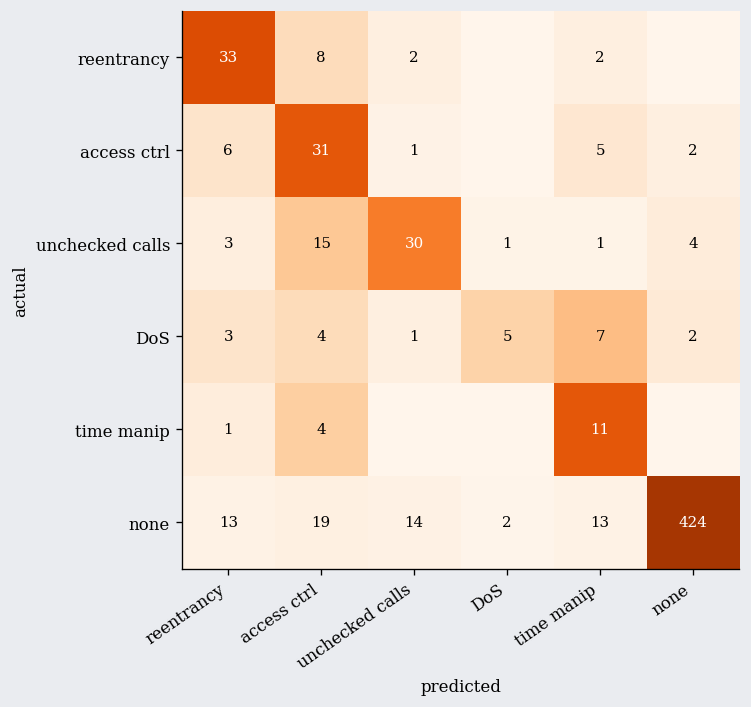

accuracy 0.801 over 667 files


In [12]:
F = json.load(open("data/stage3_scored/forced_scores.json"))
LAB = CATS + ["none"]
SHORT_N = {**SHORT, "none": "none"}

mat = np.array([[F["confusion"][t][p] for p in LAB] for t in LAB], dtype=float)
norm = mat / mat.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.4, 6))
im = ax.imshow(norm, cmap="Oranges", vmin=0, vmax=1)
ax.set_xticks(range(len(LAB))); ax.set_xticklabels([SHORT_N[l] for l in LAB], rotation=35, ha="right")
ax.set_yticks(range(len(LAB))); ax.set_yticklabels([SHORT_N[l] for l in LAB])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(len(LAB)):
    for j in range(len(LAB)):
        if mat[i, j]:
            ax.text(j, i, int(mat[i, j]), ha="center", va="center", fontsize=9,
                    color="white" if norm[i, j] > .55 else T["ink"])
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"accuracy {F['accuracy']:.3f} over {F['n_scored']} files")

→ 424 of 485 clean files are correctly called `none`, and the diagonal holds for the three categories Haiku already did well on.

→ The largest confusion is unchecked calls read as access control (15 files). DoS is the weak row: only 5 of 22 are ranked most serious, the rest scatter into time manipulation and reentrancy.

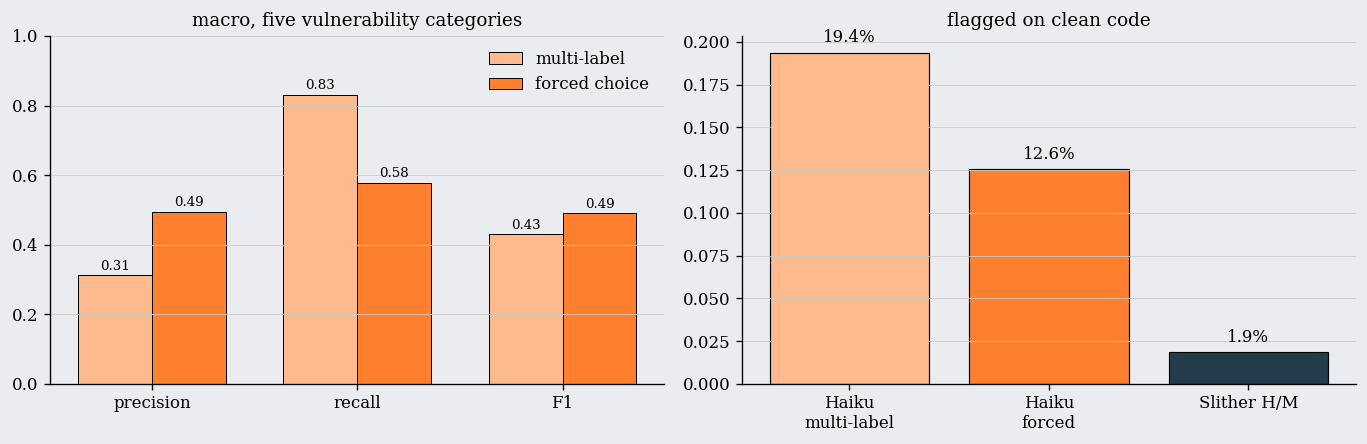

In [13]:
fc_mac = F["macro"]
ml_mac = S["pooled"]["haiku"]["macro"]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
labels = ["multi-label", "forced choice"]
x = np.arange(3); w = .36
for k, (lbl, m, col) in enumerate([("multi-label", ml_mac, "#FDBA8C"),
                                    ("forced choice", fc_mac, T["hot"])]):
    v = [m["precision"], m["recall"], m["f1"]]
    axes[0].bar(x + (k - .5)*w, v, w, label=lbl, color=col, edgecolor=T["ink"], linewidth=.6)
    for i, val in enumerate(v):
        axes[0].text(x[i]+(k-.5)*w, val+.015, f"{val:.2f}", ha="center", fontsize=8, color=T["ink"])
axes[0].set_xticks(x); axes[0].set_xticklabels(["precision", "recall", "F1"])
axes[0].set_ylim(0, 1); axes[0].legend(frameon=False); bare(axes[0])
axes[0].set_title("macro, five vulnerability categories", fontsize=11)

fp = [S["clean_fp"]["haiku"]["any"] / S["clean_fp"]["haiku"]["n_clean"],
      F["clean_fp"]["any"] / F["clean_fp"]["n_clean"],
      S["clean_fp"]["slither_hm"]["any"] / S["clean_fp"]["slither_hm"]["n_clean"]]
names = ["Haiku\nmulti-label", "Haiku\nforced", "Slither H/M"]
axes[1].bar(names, fp, color=["#FDBA8C", T["hot"], T["muted"]], edgecolor=T["ink"], linewidth=.7)
for i, v in enumerate(fp):
    axes[1].text(i, v + .006, f"{v:.1%}", ha="center", fontsize=10, color=T["ink"])
axes[1].set_title("flagged on clean code", fontsize=11); bare(axes[1])
plt.tight_layout(); plt.show()

→ Constraining the output nearly doubles precision, 0.31 to 0.49, and cuts clean-file noise from 19.4% to 12.6%. Recall falls 0.83 to 0.58, which is the cost of discarding every finding after the first.

→ Neither number is the truth. The multi-label arm over-counts false positives because the ground truth is incomplete; the forced arm under-counts real findings and scores ranking disagreements as misses. Read together they bracket it, and the gap is a measure of how much single-label ground truth distorts the result.

→ Even forced to one answer, Haiku is still six times noisier on clean code than Slither H/M.

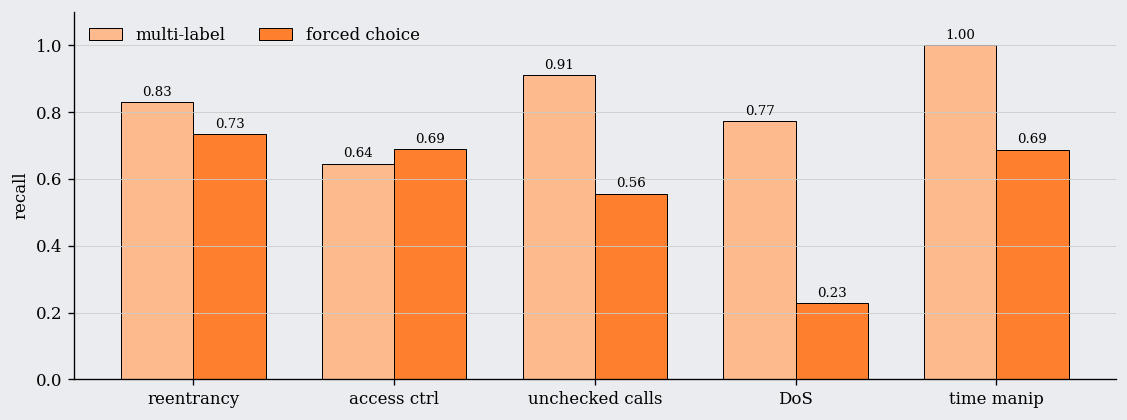

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 3.6))
x = np.arange(len(CATS)); w = .36
ml = [S["pooled"]["haiku"]["per_category"][c]["recall"] for c in CATS]
fcv = [F["per_category"][c]["recall"] for c in CATS]
ax.bar(x - w/2, ml, w, label="multi-label", color="#FDBA8C", edgecolor=T["ink"], linewidth=.6)
ax.bar(x + w/2, fcv, w, label="forced choice", color=T["hot"], edgecolor=T["ink"], linewidth=.6)
for i in range(len(CATS)):
    ax.text(x[i]-w/2, ml[i]+.02, f"{ml[i]:.2f}", ha="center", fontsize=8, color=T["ink"])
    ax.text(x[i]+w/2, fcv[i]+.02, f"{fcv[i]:.2f}", ha="center", fontsize=8, color=T["ink"])
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS])
ax.set_ylabel("recall"); ax.set_ylim(0, 1.1); ax.legend(frameon=False, ncol=2)
bare(ax); plt.tight_layout(); plt.show()

→ Denial of service collapses from 68 flags under multi-label to 8 under forced choice, recall 0.77 to 0.23. Haiku sees DoS in plenty of contracts but almost never ranks it as the most serious flaw - a difference between detecting and prioritising, not between finding and missing.

---
## 12 - Routing instead of choosing

Every attempt to make one tool cover all five categories landed at or below the individual
tools. This arm does the opposite: it asks each tool only for the categories it is good at.

**Slither H/M** answers reentrancy and unchecked low-level calls.
**Haiku forced-choice** answers access control, denial of service and time manipulation.

Nothing new was run. This is a scoring construction over results already on disk.

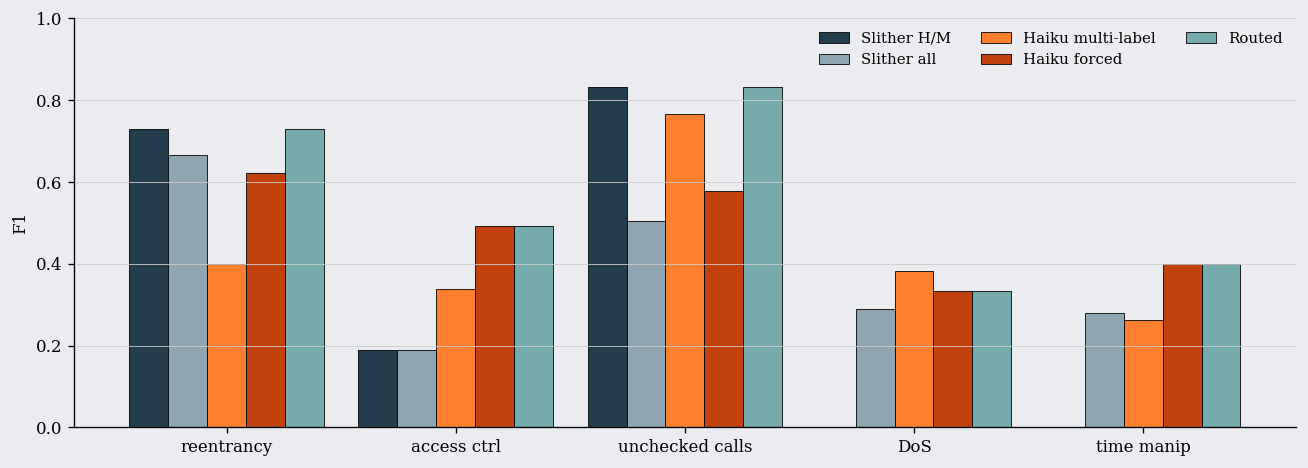

,answered by,F1,n
category,,,
reentrancy,Slither H/M,0.73,47
access ctrl,Haiku forced,0.49,45
unchecked calls,Slither H/M,0.83,56
DoS,Haiku forced,0.33,22
time manip,Haiku forced,0.40,16


In [15]:
rows = []
for c in CATS:
    src_arm = "Slither H/M" if c in ("reentrancy", "unchecked_low_level_calls") else "Haiku forced"
    rows.append({"category": SHORT[c], "answered by": src_arm,
                 "F1": round(S["pooled"]["routed"]["per_category"][c]["f1"], 2),
                 "n": S["pooled"]["routed"]["per_category"][c]["n_pos"]})

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(CATS)); w = .17
for k, a in enumerate(ARMS):
    v = [S["pooled"][a]["per_category"][c]["f1"] for c in CATS]
    ax.bar(x + (k-2)*w, v, w, label=LABEL[a], color=COLOR[a],
           edgecolor=T["ink"], linewidth=.5)
ax.set_xticks(x); ax.set_xticklabels([SHORT[c] for c in CATS])
ax.set_ylabel("F1"); ax.set_ylim(0, 1); ax.legend(frameon=False, ncol=3, fontsize=9)
bare(ax); plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("category")

→ The routed arm equals the better tool in every column by construction: 0.73, 0.83 from Slither, 0.49, 0.33, 0.40 from Haiku. Macro F1 0.56, the highest of any arm, with precision 0.53 and clean-file noise at 7.2% — a third of Haiku multi-label's.

→ It also localizes best, 0.91 exact against 0.87 and 0.80, since it inherits Slither's line numbers where Slither answers.

→ **Caveat.** The routing rule was chosen after seeing which categories each tool won, on 182 vulnerable files with two categories at n=16 and n=22. That is selection on the test set and 0.56 is optimistic. What defends it is that the split follows the syntactic/semantic line you would predict in advance, and Slither's zero on DoS and time manipulation is structural — it has no High/Medium detector for either — rather than a small-sample accident. Treat this as a hypothesis this data generated, not a measured result on par with the other rows.

---
## 13 - Verdict

Lane 1 needs to catch what later lanes will confirm, so recall matters more than precision there.

In [16]:
rows = []
for a in ARMS:
    m = S["pooled"][a]["macro"]
    cov = sum(1 for c in CATS
              if S["pooled"][a]["per_category"][c]["tp"]
               + S["pooled"][a]["per_category"][c]["fp"] > 0)
    rows.append({"arm": LABEL[a],
                 "macro P": round(m["precision"], 2),
                 "macro R": round(m["recall"], 2),
                 "macro F1": round(m["f1"], 2),
                 "clean FP": f"{S['clean_fp'][a]['any']/S['clean_fp'][a]['n_clean']:.1%}",
                 "categories covered": f"{cov}/5",
                 "exact localization": round(
                     S["localization"]["sweep"].get("0", S["localization"]["sweep"].get(0))[a], 2)})
pd.DataFrame(rows).set_index("arm")

,macro P,macro R,macro F1,clean FP,categories covered,exact localization
arm,,,,,,
Slither H/M,0.31,0.40,0.35,1.9%,3/5,0.80
Slither all,0.28,0.68,0.39,10.7%,5/5,0.85
Haiku multi-label,0.31,0.83,0.43,19.4%,5/5,0.87
Haiku forced,0.49,0.57,0.48,12.6%,5/5,0.69
Routed,0.53,0.69,0.56,7.2%,5/5,0.91


→ No single tool wins. Slither H/M owns reentrancy (0.73) and unchecked calls (0.83) at 1.9% noise on clean code, and has no detector at all for DoS or time manipulation. Haiku reaches all five but fires on 12.6–19.4% of clean files.

→ Haiku's measured precision depends heavily on the question asked — 0.31 multi-label, 0.49 forced choice. 70% of its multi-label false positives are on vulnerable files flagged with a category the label omits, and 178 of 182 vulnerable files carry exactly one label. Much of the apparent noise is incomplete ground truth.

→ Routing by category beats every individual tool and every attempt to combine them into one verdict. The two are complements with near-disjoint blind spots, not substitutes competing for one slot.

→ For lane 1 that means running both: Slither for the syntactic categories, cheaply and quietly, and the LLM for the three it cannot reach. Slither costs 1.2s and nothing; Haiku cost $1.25 for the corpus. There is no budget reason to choose.

→ The weakest part of the evidence is DAppSCAN — the source most like real audited code, and the one where 403 files became 89 at the compile step and 67 after Slither exclusions. Those survivors are the simpler import graphs, and every DAppSCAN number rests on them.